<a href="https://colab.research.google.com/github/mousamshivhare123-ops/Vaccination-Data-Analysis/blob/main/notebook/Vaccination_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

github link - https://github.com/mousamshivhare123-ops/Vaccination-Data-Analysis

# 💉 Vaccination Data Analysis

## Professional End-to-End Data Analytics Project

**Tools:** Python • Pandas • NumPy • Matplotlib • Seaborn • SQL • Excel • Power BI

### Project objective
Analyze vaccination coverage, disease cases, incidence rates, vaccine introduction, and immunization schedules to identify trends, dose-level drop-offs, coverage gaps, and exploratory relationships between vaccination coverage and disease incidence.


## 1. Business / Public-Health Questions

This project addresses the following analytical questions:

1. How does vaccination coverage change over time?
2. How do DTP1 and DTP3 coverage compare?
3. Where is there a drop-off between DTP1 and DTP3?
4. Which countries have relatively lower MCV1 coverage?
5. How do reported disease cases change over time?
6. How does disease incidence vary over time?
7. Is there an exploratory relationship between vaccination coverage and disease incidence?
8. When were selected vaccines first introduced?
9. What patterns appear in vaccination schedules and booster rounds?

## 2. Dataset Overview

Five cleaned datasets are used:

| Dataset | Purpose |
|---|---|
| `coverage.csv` | Vaccination coverage by country, year and antigen |
| `cases.csv` | Reported disease cases |
| `incidence.csv` | Disease incidence rates |
| `introduction.csv` | Vaccine introduction status and year |
| `schedule.csv` | Immunization schedule and rounds |

The datasets are stored in `data/cleaned/` when this notebook is used from the GitHub repository. In Google Colab, upload the same folder structure or change `DATA_DIR` below.

In [48]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("data/cleaned")
if not DATA_DIR.exists():
    # Helpful fallback for running the notebook from the project root with the ZIP extracted elsewhere.
    candidates = [Path("cleaned_data"), Path("../cleaned_data")]
    for candidate in candidates:
        if candidate.exists():
            DATA_DIR = candidate
            break

print("Using data directory:", DATA_DIR.resolve())

Using data directory: /content/data/cleaned


## 3. Load the Datasets

In [49]:
DATA_DIR = Path("/content") # Updated DATA_DIR to point to the correct location where files are.

coverage = pd.read_csv(DATA_DIR / "coverage.csv", on_bad_lines='skip', engine='python')
cases = pd.read_csv(DATA_DIR / "cases.csv")
incidence = pd.read_csv(DATA_DIR / "incidence.csv")
introduction = pd.read_csv(DATA_DIR / "introduction.csv")
schedule = pd.read_csv(DATA_DIR / "schedule.csv")

print("Coverage:", coverage.shape)
print("Cases:", cases.shape)
print("Incidence:", incidence.shape)
print("Introduction:", introduction.shape)
print("Schedule:", schedule.shape)

Coverage: (28015, 11)
Cases: (38183, 7)
Incidence: (24482, 8)
Introduction: (56604, 6)
Schedule: (8053, 12)


In [50]:
datasets = {
    "coverage": coverage,
    "cases": cases,
    "incidence": incidence,
    "introduction": introduction,
    "schedule": schedule,
}

summary = pd.DataFrame({
    "dataset": list(datasets.keys()),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()],
    "missing_cells": [int(df.isna().sum().sum()) for df in datasets.values()],
    "duplicate_rows": [int(df.duplicated().sum()) for df in datasets.values()],
})
summary

,dataset,rows,columns,missing_cells,duplicate_rows
0,coverage,28015,11,60638,0
1,cases,38183,7,8435,0
2,incidence,24482,8,6652,0
3,introduction,56604,6,0,0
4,schedule,8053,12,8256,0


## 4. Data Quality Checks

The first stage checks missing values, duplicate records, data types, and year ranges. This is important because the five datasets have different structures and measurement fields.

In [51]:
for name, df in datasets.items():
    print(f"\n{name.upper()} DATA TYPES")
    display(df.dtypes.to_frame("dtype"))

print("\nMissing values")
display(pd.DataFrame({name: df.isna().sum() for name, df in datasets.items()}).fillna(0).astype(int))


COVERAGE DATA TYPES


,dtype
GROUP,object
CODE,object
NAME,object
YEAR,int64
ANTIGEN,object
ANTIGEN_DESCRIPTION,object
COVERAGE_CATEGORY,object
COVERAGE_CATEGORY_DESCRIPTION,object
TARGET_NUMBER,float64
DOSES,float64



CASES DATA TYPES


,dtype
GROUP,object
CODE,object
NAME,object
YEAR,int64
DISEASE,object
DISEASE_DESCRIPTION,object
CASES,float64



INCIDENCE DATA TYPES


...

,dtype
ISO_3_CODE,object
COUNTRYNAME,object
WHO_REGION,object
YEAR,int64
DESCRIPTION,object
INTRO,object



SCHEDULE DATA TYPES


,dtype
ISO_3_CODE,object
COUNTRYNAME,object
WHO_REGION,object
YEAR,float64
VACCINECODE,object
VACCINE_DESCRIPTION,object
SCHEDULEROUNDS,float64
TARGETPOP,object
TARGETPOP_DESCRIPTION,object
GEOAREA,object



Missing values


,coverage,cases,incidence,introduction,schedule
AGEADMINISTERED,0,0,0,0,1046
ANTIGEN,0,0,0,0,0
ANTIGEN_DESCRIPTION,0,0,0,0,0
CASES,0,8433,0,0,0
CODE,0,0,0,0,0
COUNTRYNAME,0,0,0,0,1
COVERAGE,12820,0,0,0,0
COVERAGE_CATEGORY,0,0,0,0,0
COVERAGE_CATEGORY_DESCRIPTION,0,0,0,0,0
DENOMINATOR,0,0,1,0,0


In [52]:
for name, df in datasets.items():
    if "YEAR" in df.columns:
        years = pd.to_numeric(df["YEAR"], errors="coerce").dropna()
        print(f"{name}: {int(years.min())} to {int(years.max())}")

# Standardize year fields where applicable.
for df in [coverage, cases, incidence, introduction, schedule]:
    if "YEAR" in df.columns:
        df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
        df["YEAR"] = df["YEAR"].round().astype("Int64")

# Numeric measures.
for df, cols in [
    (coverage, ["TARGET_NUMBER", "DOSES", "COVERAGE"]),
    (cases, ["CASES"]),
    (incidence, ["INCIDENCE_RATE"]),
    (schedule, ["SCHEDULEROUNDS"]),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

print("Standardization complete.")

coverage: 1980 to 2023
cases: 1980 to 2023
incidence: 1980 to 2023
introduction: 1940 to 2023
schedule: 2019 to 2023
Standardization complete.


## 5. Exploratory Data Analysis — Vaccination Coverage

In [53]:
# Focus on official/WUENIC-style coverage estimates where available.
coverage_analytic = coverage.copy()
wu = coverage_analytic[coverage_analytic["COVERAGE_CATEGORY"].astype(str).str.upper().eq("WUENIC")].copy()

print("WUENIC rows:", len(wu))
print("Antigens available:", wu["ANTIGEN"].nunique())
print("Countries available:", wu["CODE"].nunique())

wu["COVERAGE"] = pd.to_numeric(wu["COVERAGE"], errors="coerce")
wu = wu[(wu["COVERAGE"].between(0, 100)) | wu["COVERAGE"].isna()].copy()
wu.head()

WUENIC rows: 5683
Antigens available: 16
Countries available: 15


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
474,COUNTRIES,AFG,Afghanistan,2023,BCG,BCG,WUENIC,WHO/UNICEF Estimates of National Immunization ...,NaN,NaN,68.00
483,COUNTRIES,AFG,Afghanistan,2023,DTPCV1,"DTP-containing vaccine, 1st dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,NaN,NaN,67.00
486,COUNTRIES,AFG,Afghanistan,2023,DTPCV3,"DTP-containing vaccine, 3rd dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,NaN,NaN,60.00
499,COUNTRIES,AFG,Afghanistan,2023,HEPB_BD,"HepB, birth dose (given within 24 hours of birth)",WUENIC,WHO/UNICEF Estimates of National Immunization ...,NaN,NaN,55.00
504,COUNTRIES,AFG,Afghanistan,2023,HEPB3,"HepB, 3rd dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,NaN,NaN,60.00


,YEAR,ANTIGEN,COVERAGE
0,1980,DTPCV1,68.62
1,1980,DTPCV3,53.12
2,1980,MCV1,49.00
3,1981,DTPCV1,81.50
4,1981,DTPCV3,59.00
5,1981,MCV1,52.00
6,1982,DTPCV1,76.22
7,1982,DTPCV3,60.67
8,1982,MCV1,47.43
9,1983,DTPCV1,74.30


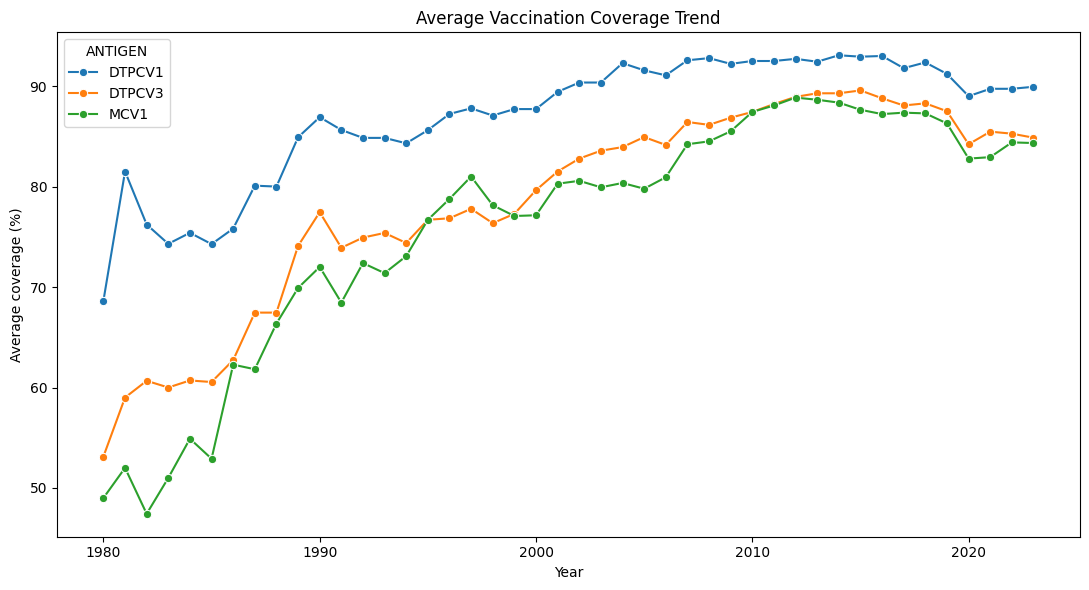

In [54]:
# Annual average coverage for common vaccine indicators.
trend_antigens = [a for a in ["DTPCV1", "DTPCV3", "MCV1"] if a in wu["ANTIGEN"].unique()]
trend = (wu[wu["ANTIGEN"].isin(trend_antigens)]
         .groupby(["YEAR", "ANTIGEN"], as_index=False)["COVERAGE"]
         .mean())

display(trend.head(15))

plt.figure(figsize=(11, 6))
sns.lineplot(data=trend, x="YEAR", y="COVERAGE", hue="ANTIGEN", marker="o")
plt.title("Average Vaccination Coverage Trend")
plt.xlabel("Year")
plt.ylabel("Average coverage (%)")
plt.tight_layout()
plt.show()

## 6. DTP1 vs DTP3 Coverage and Drop-off

DTP1 and DTP3 are compared to examine whether coverage decreases between the first and third dose. This is an important program-monitoring metric because a gap can indicate incomplete continuation through the vaccination series.

ANTIGEN,DTPCV1,DTPCV3,DTP1_to_DTP3_dropoff
YEAR,,,
2009,92.21,86.86,5.36
2010,92.50,87.43,5.07
2011,92.50,88.21,4.29
2012,92.71,88.93,3.79
2013,92.43,89.29,3.14
2014,93.07,89.29,3.79
2015,92.93,89.57,3.36
2016,93.00,88.79,4.21
2017,91.79,88.07,3.71


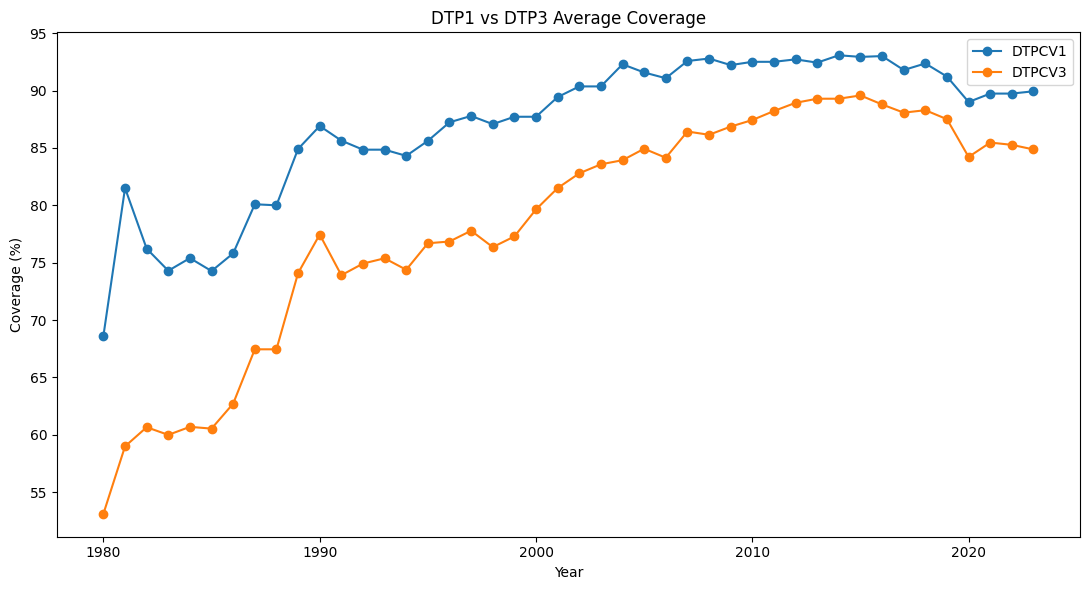

In [55]:
dtp = wu[wu["ANTIGEN"].isin(["DTPCV1", "DTPCV3"])].copy()
dtp_avg = dtp.groupby(["YEAR", "ANTIGEN"], as_index=False)["COVERAGE"].mean()

dtp_pivot = dtp_avg.pivot(index="YEAR", columns="ANTIGEN", values="COVERAGE")
dtp_pivot["DTP1_to_DTP3_dropoff"] = dtp_pivot.get("DTPCV1") - dtp_pivot.get("DTPCV3")

display(dtp_pivot.tail(15))

plt.figure(figsize=(11, 6))
for col in ["DTPCV1", "DTPCV3"]:
    if col in dtp_pivot.columns:
        plt.plot(dtp_pivot.index, dtp_pivot[col], marker="o", label=col)
plt.title("DTP1 vs DTP3 Average Coverage")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.legend()
plt.tight_layout()
plt.show()

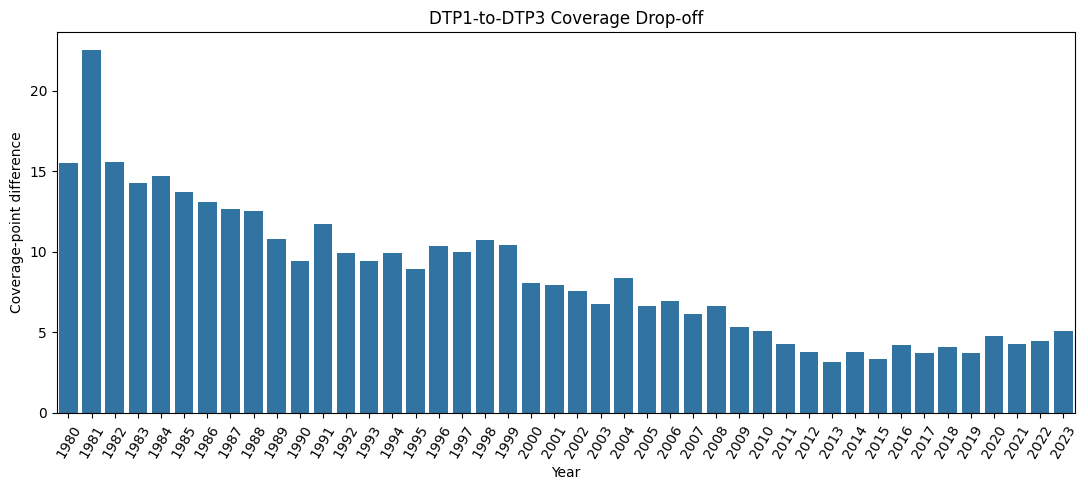

ANTIGEN,YEAR,DTP1_to_DTP3_dropoff
1,1981,22.50
2,1982,15.56
0,1980,15.50
4,1984,14.70
3,1983,14.30
5,1985,13.73
6,1986,13.09
7,1987,12.64
8,1988,12.55
11,1991,11.73


In [56]:
dropoff = dtp_pivot.reset_index()[["YEAR", "DTP1_to_DTP3_dropoff"]].dropna()
if not dropoff.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(data=dropoff, x="YEAR", y="DTP1_to_DTP3_dropoff")
    plt.xticks(rotation=60)
    plt.title("DTP1-to-DTP3 Coverage Drop-off")
    plt.xlabel("Year")
    plt.ylabel("Coverage-point difference")
    plt.tight_layout()
    plt.show()

display(dropoff.sort_values("DTP1_to_DTP3_dropoff", ascending=False).head(10))

## 7. MCV1 Country Coverage — 2023

,CODE,NAME,COVERAGE
1,AGO,Angola,50.00
13,BEN,Benin,52.00
0,AFG,Afghanistan,55.00
5,ARG,Argentina,80.00
2,ALB,Albania,83.00
11,BDI,Burundi,86.00
8,AUS,Australia,91.00
7,ATG,Antigua and Barbuda,94.00
14,BFA,Burkina Faso,94.00
9,AUT,Austria,95.00


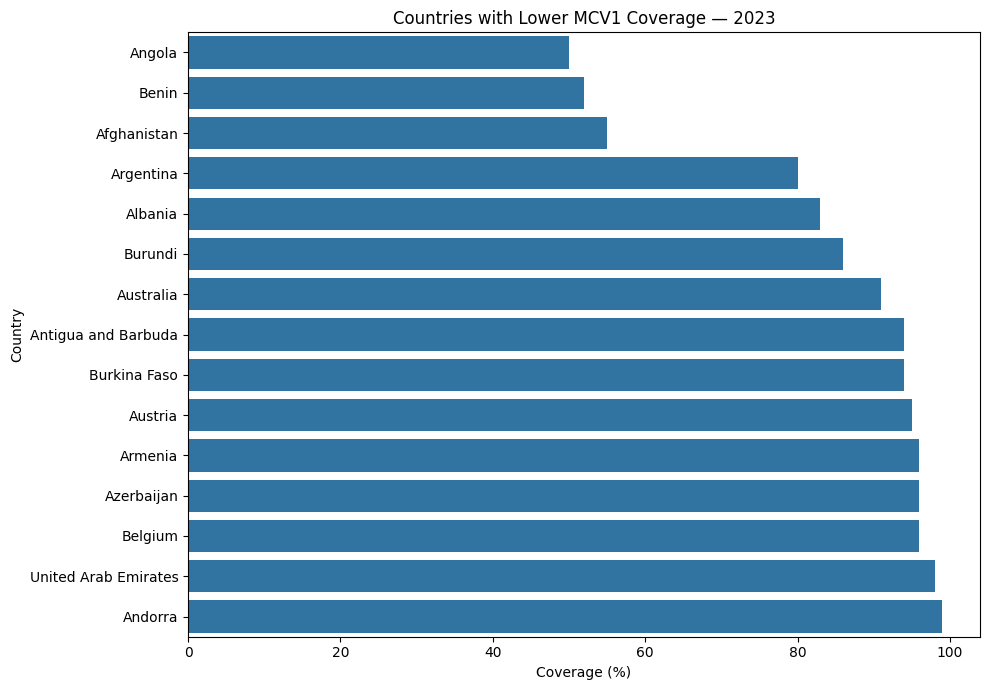

In [57]:
mcv1 = wu[(wu["ANTIGEN"] == "MCV1") & (wu["YEAR"] == 2023)].copy()
mcv1_country = (mcv1.groupby(["CODE", "NAME"], as_index=False)["COVERAGE"].mean()
                 .sort_values("COVERAGE", ascending=True))

display(mcv1_country.head(15))

plt.figure(figsize=(10, 7))
top_low = mcv1_country.head(15).sort_values("COVERAGE", ascending=True)
sns.barplot(data=top_low, x="COVERAGE", y="NAME")
plt.title("Countries with Lower MCV1 Coverage — 2023")
plt.xlabel("Coverage (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 8. Reported Disease Cases

In [58]:
cases["CASES"] = pd.to_numeric(cases["CASES"], errors="coerce")
annual_cases = cases.groupby(["YEAR", "DISEASE_DESCRIPTION"], as_index=False)["CASES"].sum()

display(annual_cases.head(15))

# Top diseases by total reported cases across the available period.
top_diseases = (cases.groupby("DISEASE_DESCRIPTION")["CASES"].sum()
                .sort_values(ascending=False).head(8))
display(top_diseases.to_frame("total_reported_cases"))

,YEAR,DISEASE_DESCRIPTION,CASES
0,1980,Diphtheria,"71,285.00"
1,1980,Measles,"2,301,961.00"
2,1980,Neonatal tetanus,"6,583.00"
3,1980,Pertussis,"1,342,875.00"
4,1980,Poliomyelitis,"34,975.00"
5,1980,Total tetanus,"79,077.00"
6,1980,Yellow fever,102.00
7,1981,Diphtheria,"49,265.00"
8,1981,Measles,"2,460,974.00"
9,1981,Neonatal tetanus,"7,057.00"


,total_reported_cases
DISEASE_DESCRIPTION,
Measles,"27,555,680.00"
Pertussis,"11,265,699.00"
Mumps,"9,001,860.00"
Typhoid,"8,280,114.00"
Rubella,"1,411,450.00"
Total tetanus,"1,106,595.00"
Diphtheria,"558,770.00"
Poliomyelitis,"418,158.00"


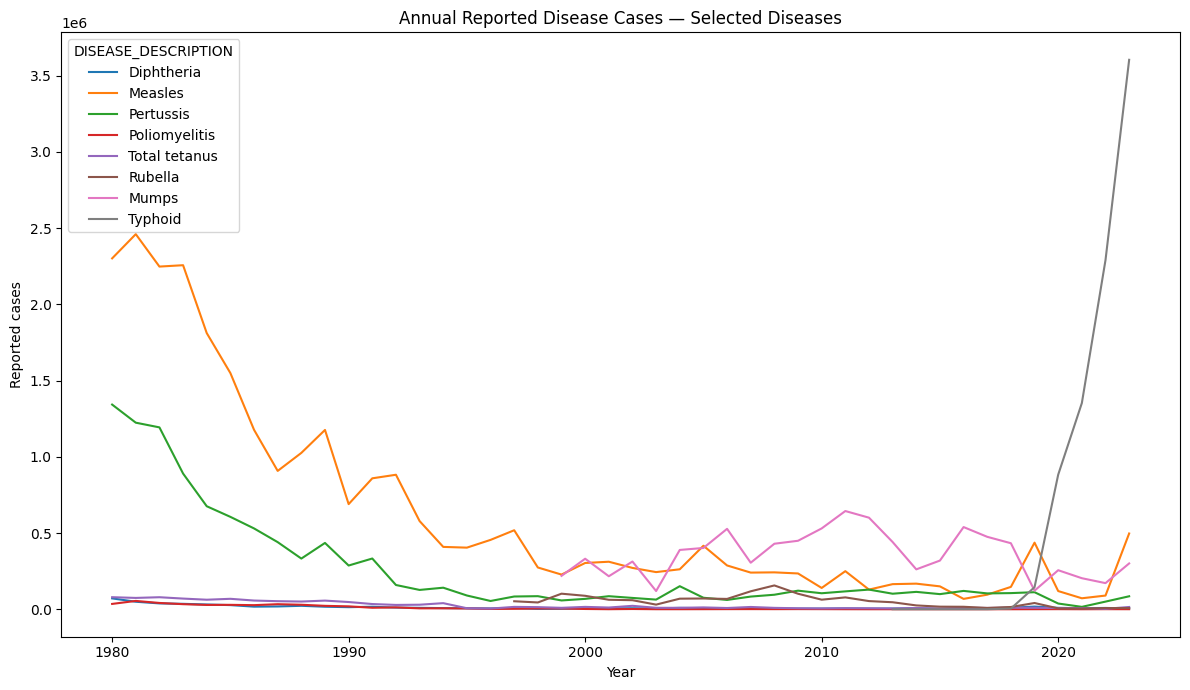

In [59]:
plot_df = annual_cases[annual_cases["DISEASE_DESCRIPTION"].isin(top_diseases.index)]
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="YEAR", y="CASES", hue="DISEASE_DESCRIPTION")
plt.title("Annual Reported Disease Cases — Selected Diseases")
plt.xlabel("Year")
plt.ylabel("Reported cases")
plt.tight_layout()
plt.show()

## 9. Disease Incidence Analysis

In [60]:
incidence["INCIDENCE_RATE"] = pd.to_numeric(incidence["INCIDENCE_RATE"], errors="coerce")
annual_incidence = incidence.groupby(["YEAR", "DISEASE_DESCRIPTION"], as_index=False)["INCIDENCE_RATE"].mean()

display(annual_incidence.head(15))

top_incidence_diseases = (incidence.groupby("DISEASE_DESCRIPTION")["INCIDENCE_RATE"].mean()
                           .sort_values(ascending=False).head(8))
display(top_incidence_diseases.to_frame("mean_incidence_rate"))

,YEAR,DISEASE_DESCRIPTION,INCIDENCE_RATE
0,1980,Diphtheria,33.98
1,1980,Measles,"3,148.48"
2,1980,Neonatal tetanus,0.14
3,1980,Pertussis,598.93
4,1980,Poliomyelitis,NaN
5,1980,Total tetanus,31.38
6,1980,Yellow fever,1.92
7,1981,Diphtheria,8.13
8,1981,Measles,"1,870.68"
9,1981,Neonatal tetanus,0.16


,mean_incidence_rate
DISEASE_DESCRIPTION,
Typhoid,533.63
Measles,437.57
Mumps,181.19
Pertussis,105.58
Rubella,67.69
Total tetanus,8.16
Invasive meningococcal disease,4.62
Diphtheria,2.76


## 10. Coverage vs Disease Incidence — Exploratory Correlation

To explore whether vaccination coverage and disease incidence move together, country-year observations are aligned using a common key. Because different vaccines and diseases use different units and denominators, this is treated as an exploratory analysis rather than a causal model.

Matched country-year observations: 501


,CODE,NAME,YEAR,MCV1_COVERAGE,MEASLES_INCIDENCE
0,AFG,Afghanistan,2023,55.00,67.40
1,AFG,Afghanistan,2022,56.00,127.30
2,AFG,Afghanistan,2021,51.00,72.50
3,AFG,Afghanistan,2020,57.00,16.40
4,AFG,Afghanistan,2019,57.00,9.30


Pearson correlation: -0.186


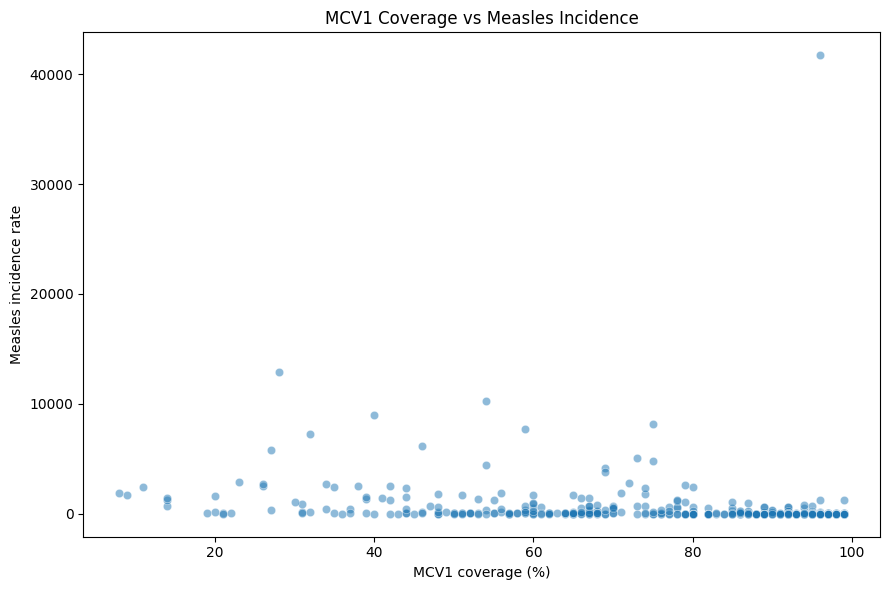

In [61]:
# Use MCV1 coverage and measles incidence as a focused example.
mc = wu[(wu["ANTIGEN"] == "MCV1")][["CODE", "NAME", "YEAR", "COVERAGE"]].copy()
mc = mc.rename(columns={"COVERAGE": "MCV1_COVERAGE"})

measles = incidence[incidence["DISEASE"] == "MEASLES"][["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]].copy()
measles = measles.rename(columns={"INCIDENCE_RATE": "MEASLES_INCIDENCE"})

merged = mc.merge(measles, on=["CODE", "NAME", "YEAR"], how="inner").dropna()
print("Matched country-year observations:", len(merged))

display(merged.head())

if len(merged) >= 3:
    corr = merged[["MCV1_COVERAGE", "MEASLES_INCIDENCE"]].corr().iloc[0, 1]
    print(f"Pearson correlation: {corr:.3f}")

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=merged, x="MCV1_COVERAGE", y="MEASLES_INCIDENCE", alpha=0.5)
    plt.title("MCV1 Coverage vs Measles Incidence")
    plt.xlabel("MCV1 coverage (%)")
    plt.ylabel("Measles incidence rate")
    plt.tight_layout()
    plt.show()

## 11. Vaccine Introduction Analysis

In [62]:
intro = introduction.copy()
intro["YEAR"] = pd.to_numeric(intro["YEAR"], errors="coerce")

# Treat statuses beginning with Yes as an introduction signal.
intro_yes = intro[intro["INTRO"].astype(str).str.startswith("Yes", na=False)].copy()
first_intro = (intro_yes.groupby(["COUNTRYNAME", "DESCRIPTION"], as_index=False)["YEAR"].min()
               .rename(columns={"YEAR": "FIRST_INTRODUCTION_YEAR"}))

display(first_intro.head(20))

# Example: count first introductions by year.
intro_by_year = first_intro.groupby("FIRST_INTRODUCTION_YEAR").size().reset_index(name="new_country_vaccine_introductions")
display(intro_by_year.sort_values("FIRST_INTRODUCTION_YEAR").head(20))

,COUNTRYNAME,DESCRIPTION,FIRST_INTRODUCTION_YEAR
0,Afghanistan,HepB birth dose,2014
1,Afghanistan,Hepatitis B vaccine,2006
2,Afghanistan,Hib (Haemophilus influenzae type B) vaccine,2009
3,Afghanistan,IPV (Inactivated polio vaccine),2015
4,Afghanistan,IPV (Inactivated polio vaccine) 2nd dose,2020
5,Afghanistan,Measles-containing vaccine 2nd dose,2004
6,Afghanistan,PCV (Pneumococcal conjugate vaccine),2014
7,Afghanistan,Rotavirus vaccine,2018
8,Albania,HPV (Human Papilloma Virus) vaccine,2022
9,Albania,HepB birth dose,1998


,FIRST_INTRODUCTION_YEAR,new_country_vaccine_introductions
0,1955,2
1,1957,2
2,1959,1
3,1962,1
4,1963,1
5,1964,1
6,1970,3
7,1972,3
8,1973,2
9,1974,2


## 12. Immunization Schedule and Booster Rounds

In [63]:
schedule["SCHEDULEROUNDS"] = pd.to_numeric(schedule["SCHEDULEROUNDS"], errors="coerce")
schedule_summary = (schedule.groupby(["YEAR", "VACCINE_DESCRIPTION"], as_index=False)["SCHEDULEROUNDS"].max())

display(schedule_summary.head(20))

booster_like = schedule[schedule["SCHEDULEROUNDS"] >= 2].copy()
booster_trend = booster_like.groupby("YEAR").size().reset_index(name="schedule_records_with_2plus_rounds")
display(booster_trend)

,YEAR,VACCINE_DESCRIPTION,SCHEDULEROUNDS
0,2019,Adult Hepatitis B vaccine,3.00
1,2019,Adult seasonal influenza vaccine,1.00
2,2019,BCG (Baccille Calmette Guérin) vaccine,1.00
3,2019,"DT (Tetanus toxoid and diphtheria, children's ...",5.00
4,2019,DT-IPV (Diphtheria and tetanus toxoid and IPV)...,6.00
5,2019,DTaP-Hib-HepB-IPV (acellular) vaccine,3.00
6,2019,DTaP-Hib-IPV (acellular) vaccine,4.00
7,2019,DTaP-IPV (acellular) vaccine,4.00
8,2019,DTwP (Whole cell) vaccine,5.00
9,2019,DTwP-Hib-HepB (Whole cell) vaccine,4.00


,YEAR,schedule_records_with_2plus_rounds
0,2019,56
1,2021,12
2,2022,21
3,2023,4114


## 13. Key Findings

Based on the exploratory analysis above, the main areas of insight are:

- Vaccination coverage can be compared across years, countries, and vaccine indicators.
- DTP1-to-DTP3 differences provide a simple measure of dose-series drop-off.
- MCV1 analysis highlights country-level variation in measles-containing vaccine coverage.
- Disease-case and incidence analysis provides a view of disease burden over time.
- Vaccine introduction data supports analysis of when specific vaccines were introduced in different countries.
- Schedule data supports analysis of dose rounds and booster-related patterns.
- Coverage-incidence correlation is useful for exploration but should not be interpreted as proof of causality.

For formal reporting, the project also contains prepared CSV outputs and figures in the `outputs/` and `figures/` folders.

## 14. Project Deliverables

The GitHub project contains:

- Python analysis script
- Cleaned datasets
- SQL schema and analytical queries
- Excel analysis workbooks
- Visualization figures
- Analysis output CSV files
- Professional PDF report
- Power BI dashboard specification and build guide
- This Jupyter/Colab notebook

### Repository workflow

**Data → Cleaning → EDA → Python Analysis → SQL → Visualization → Reporting → Dashboard Planning**

## 15. Conclusion

This project demonstrates an end-to-end data analytics workflow applied to vaccination and public-health datasets. It combines data preparation, exploratory analysis, statistical exploration, visualization, SQL querying, Excel reporting, and Power BI planning into one portfolio project.

The analysis is designed to support exploratory understanding of vaccination coverage, disease patterns, and immunization-program indicators while clearly separating descriptive findings from causal claims.

## 👨‍💻 Author

**Mousam Shivhare**  
B.Sc. (Hons.) Agriculture | Data Analytics & Business Analytics Enthusiast

- GitHub: https://github.com/mousamshivhare123-ops
- LinkedIn: https://www.linkedin.com/in/mousam-shivhare